In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [80]:
divisions = 10000

I_S = 2.52e-9
eta = 1.752
R_1 = 33000.0
V_T = 25.864e-3
V_in_scal = 0.3308173308173308
V_out_scal = 4.163372493981558

max_amplitude = 8

x = np.linspace(1e-11, max_amplitude, divisions)
input = np.full(divisions, np.log(R_1 * I_S / (eta * V_T))) + np.abs(x * V_in_scal) / (eta * V_T)
Psi = scipy.special.wrightomega(input).real

a1: -49163309636221.375
b0: 201412416650939.2, b1: -1.3781155310417945
a1: -49163309636221.375
b0: 201412416650939.2, b1: -1.3781155310417945
a1: -49163309636221.375
b0: 201412416650939.2, b1: -1.3781155310417945
a1: -49163309636221.38
b0: 201412416650939.25, b1: -1.3781155310417945
a1: -49163309636221.6
b0: 201412416650940.1, b1: -1.3781155310417945
a1: -49163309636231.29
b0: 201412416650978.44, b1: -1.3781155310417945
a1: -49163309636643.05
b0: 201412416652633.8, b1: -1.3781155310417945
a1: -49163309653737.13
b0: 201412416722114.84, b1: -1.3781155310417945
a1: -49163310350864.2
b0: 201412419579307.72, b1: -1.3781155310417945
a1: 382468.561833574
b0: -3882123.1682589375, b1: -1.3781155310417945
a1: 382468.56183122355
b0: -3882123.168252116, b1: -1.3781155310417945
a1: 382468.5618142665
b0: -3882123.168191689, b1: -1.3781155310417945
a1: 382468.5540745001
b0: -3882123.1393035944, b1: -1.3781155310417945
a1: 382468.12035142863
b0: -3882121.459714629, b1: -1.3781155310417945
a1: 382451.2

array([-6.22729428e-01,  1.07155879e-01, -1.13339678e-02,  7.36620422e-04,
       -2.94621547e-05,  7.05228624e-07, -9.25031972e-09,  5.10699803e-11])

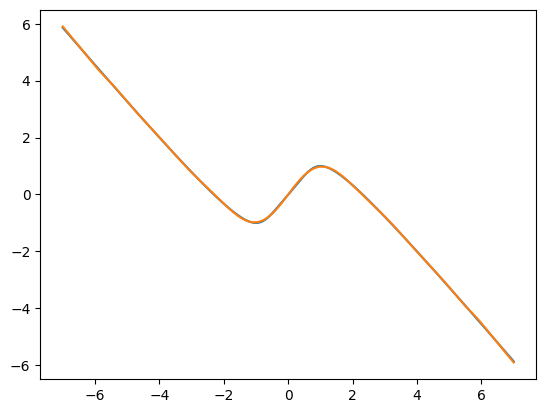

In [ ]:
# Spline fit for f

# FITTED WITH max_amplitude = 7
max_amplitude = 7
x = np.linspace(-max_amplitude, max_amplitude, divisions)
input = np.full(divisions, np.log(R_1 * I_S / (eta * V_T))) + np.abs(x * V_in_scal) / (eta * V_T)
Psi = scipy.special.wrightomega(input).real

f = (x * V_in_scal - 2 * np.sign(x) * eta * V_T * Psi) * V_out_scal
# V_in_scal = x[np.argmax(f)] # 0.3308173308173308. Set this to the "x" value for in_buf[i] = +-1.0
# V_out_scal = 1 / np.max(f) # 4.163372493981558. scale by this so audio_out_buf[i] should equal +=1.0 when in_buf[i] = +-1.0

def f_spline(x, a3, a5, a7, a9, a11, a13, a15, a17):
    knot = 6
    slope = -1.3781155310417945 # for linear section

    a1 = slope - (
        17 * a17 * knot**16 +
        15 * a15 * knot**14 +
        13 * a13 * knot**12 +
        11 * a11 * knot**10 +
        9 * a9 * knot**8 +
        7 * a7 * knot**6 +
        5 * a5 * knot**4 +
        3 * a3 * knot**2
    )
    
    print(f"a1: {a1}")
    f_knot = a17 * knot**17 + a15 * knot**15 + a13 * knot**13 + a11 * knot**11 + a9 * knot**9 + a7 * knot**7 + a5 * knot**5 + a3 * knot**3 + a1 * knot

    condlist = [x < -knot, (x >= -knot) & (x <= knot), x > knot]
    funclist = [
        lambda x_: slope * (x_ + knot) - f_knot,
        lambda x_: a17 * x_**17 + a15 * x_**15 + a13 * x_**13 + a11 * x_**11 + a9 * x_**9 + a7 * x_**7 + a5 * x_**5 + a3 * x_**3 + a1 * x_,
        lambda x_: slope * (x_ - knot) + f_knot
    ]

    print(f"b0: {f_knot / slope}, b1: {slope}")
    
    return np.piecewise(x, condlist, funclist)

# p0 = [ -1.59827070e-01, -2.08461511e+00,  5.99262019e-01, -9.98697518e-02,
        # 9.58758785e-03, -4.91431895e-04,  1.04041262e-05,  1.04928597e+01]
f_coeffs, _ = scipy.optimize.curve_fit(f_spline, x, f, maxfev=30000)
f_hat = f_spline(x, *f_coeffs)

plt.plot(x, f)
plt.plot(x, f_hat)
f_coeffs

[-1000. -1000. -1000. -1000. -1000. -1000.     4.  1000.  1000.  1000.
  1000.  1000.  1000.]
[[-4.30188754e-10 -4.30188754e-10 -4.30188754e-10 -4.30188754e-10
  -4.30188754e-10 -4.30188754e-10  3.91530389e-10  3.91530389e-10
   3.91530389e-10  3.91530389e-10  3.91530389e-10  3.91530389e-10]
 [ 1.70741063e-06  1.70741063e-06  1.70741063e-06  1.70741063e-06
   1.70741063e-06  1.70741063e-06 -4.52136915e-07  1.49768442e-06
   1.49768442e-06  1.49768442e-06  1.49768442e-06  1.49768442e-06]
 [-2.50354016e-03 -2.50354016e-03 -2.50354016e-03 -2.50354016e-03
  -2.50354016e-03 -2.50354016e-03  1.70494632e-05  2.09978010e-03
   2.09978010e-03  2.09978010e-03  2.09978010e-03  2.09978010e-03]
 [ 9.52688459e-01  9.52688459e-01  9.52688459e-01  9.52688459e-01
   9.52688459e-01  9.52688459e-01 -6.15108051e-01  6.13181351e-01
   6.13181351e-01  6.13181351e-01  6.13181351e-01  6.13181351e-01]
 [ 9.24370832e+02  9.24370832e+02  9.24370832e+02  9.24370832e+02
   9.24370832e+02  9.24370832e+02 -7.0957740

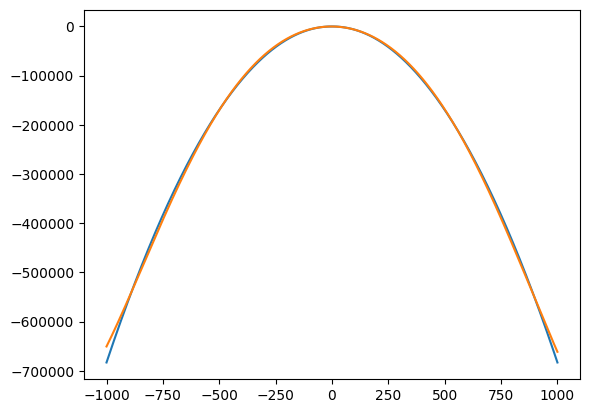

In [ ]:
# OUTDATED: spline fit for F (turns out we actually need to integrate f)

# FITTED WITH max_amplitude = 1000
# note: F_ is even

max_amplitude = 1000

x = np.linspace(-max_amplitude, max_amplitude, divisions)
input = np.full(divisions, np.log(R_1 * I_S / (eta * V_T))) + np.abs(x * V_in_scal) / (eta * V_T)
Psi = scipy.special.wrightomega(input).real

F = ((x * V_in_scal)**2 / 2 - (eta * V_T)**2 * Psi * (Psi + 2)) * V_out_scal / V_in_scal # V_in_scal comes from chain rule

knot = [4]
weight = 1 / (x + 1)**2
F_spline = scipy.interpolate.LSQUnivariateSpline(x, F, w=weight, t=knot, k=5)
F_hat = F_spline(x)

F_spline_poly = scipy.interpolate.PPoly.from_spline(F_spline._eval_args)
print(F_spline_poly.x)
print(F_spline_poly.c)

plt.plot(x, F)
plt.plot(x, F_hat)

# resulting polynomials:
# left segment: F_1(x) = -2.76592030e-03 * x^5 + 5.53185312e-02 * x^4 - 4.42626498e-01 * x^3 + 1.10046950e+00 * x^2 - 1.43743050e-01 * x + 9.90629935e-03
# right segment: F_2(x) = -6.56314568e-11 * (x-4)^5 + 1.25308733e-07 * (x-4)^4 - 7.72455768e-05 * (x-4)^3 - 6.70658466e-01 * (x-4)^2 - 1.96489293e+00 * (x-4) + 4.35918500e-02
#                       = -6.56314568e-11 * x^5 + 1.26621362e-07 * x^4 - 7.92610176e-05 * x^3 - 6.69719447e-01 * x^2 + 3.39663485e+00 * x - 2.82239602e+00

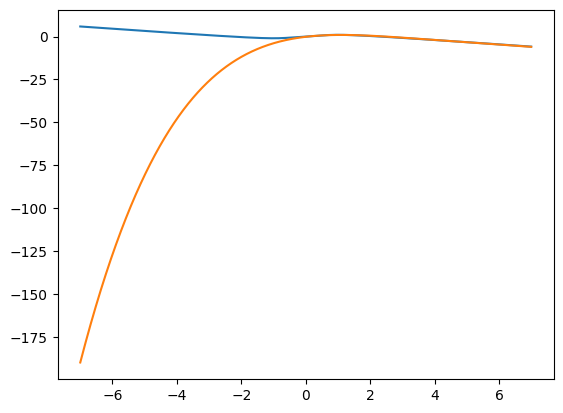

In [ ]:
# attempting to get f by differentiating the above spline for F

derivative = F_spline_poly.derivative()

max_amplitude = 7
x = np.linspace(-max_amplitude, max_amplitude, divisions)
input = np.full(divisions, np.log(R_1 * I_S / (eta * V_T))) + np.abs(x * V_in_scal) / (eta * V_T)
Psi = scipy.special.wrightomega(input).real

f = (x * V_in_scal - 2 * np.sign(x) * eta * V_T * Psi) * V_out_scal

plt.plot(x, f)
plt.plot(x, derivative(x))

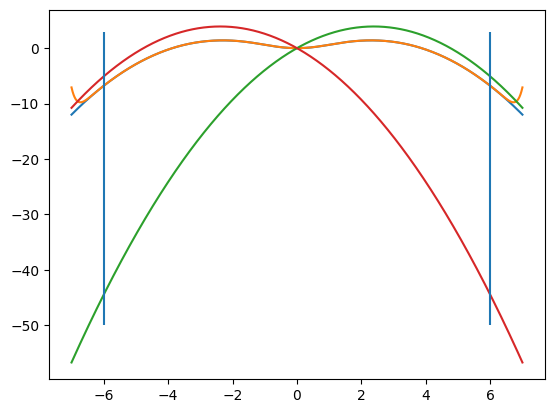

In [ ]:
# final successful attempt to get F by differentiating the earlier degree-17 odd spline for f

max_amplitude = 7
x = np.linspace(-max_amplitude, max_amplitude, divisions)
input = np.full(divisions, np.log(R_1 * I_S / (eta * V_T))) + np.abs(x * V_in_scal) / (eta * V_T)
Psi = scipy.special.wrightomega(input).real

a1 = 1.5022530851068352
a3 = -6.22729428e-01
a5 = 1.07155879e-01
a7 = -1.13339678e-02
a9 = 7.36620422e-04
a11 = -2.94621547e-05
a13 = 7.05228624e-07
a15 = -9.25031972e-09
a17 = 5.10699803e-11
b0 = 3.284071965157672
b1 = -1.3781155310417945

F1_hat = a17 / 18 * x**18 + a15 / 16 * x**16 + a13 / 14 * x**14 + a11 / 12 * x**12 + a9 / 10 * x**10 + a7 / 8 * x**8 + a5 / 6 * x**6 + a3 / 4 * x**4 + a1 / 2 * x**2
F2_hat = b1 / 2 * x**2 + b0 * x
F0_hat = b1 / 2 * x**2 - b0 * x

F = ((x * V_in_scal)**2 / 2 - (eta * V_T)**2 * Psi * (Psi + 2)) * V_out_scal / V_in_scal

plt.plot(x, F)
plt.plot(x, F1_hat)
plt.plot(x, F2_hat)
plt.plot(x, F0_hat)
plt.vlines(6, -50, 3)
plt.vlines(-6, -50, 3)

nice reading: https://ccrma.stanford.edu/~jatin/Notebooks/adaa.html